[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jennieh/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[*********************100%***********************]  1 of 1 completed



=== Base Model 2023 Test Performance ===
R²: 0.0912
MSE: 1432.4078
RMSE: 37.8472
MAE: 30.7542

=== Base Model January 2024 Performance ===
R²: -0.5639
MSE: 622.4621
RMSE: 24.9492
MAE: 22.3308


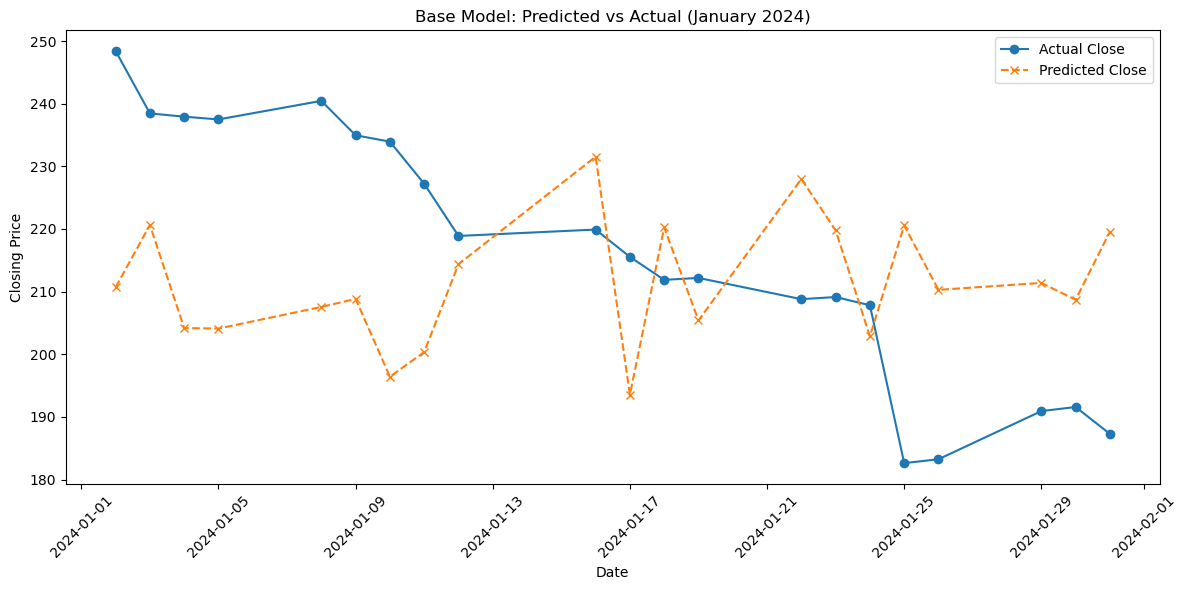


=== SMA-Based Lag Model 2023 Test Performance ===
R²: 0.9877
MSE: 13.0181
RMSE: 3.6081
MAE: 2.5416

=== SMA-Based Lag Model January 2024 Performance ===
R²: 0.9346
MSE: 26.0316
RMSE: 5.1021
MAE: 3.439


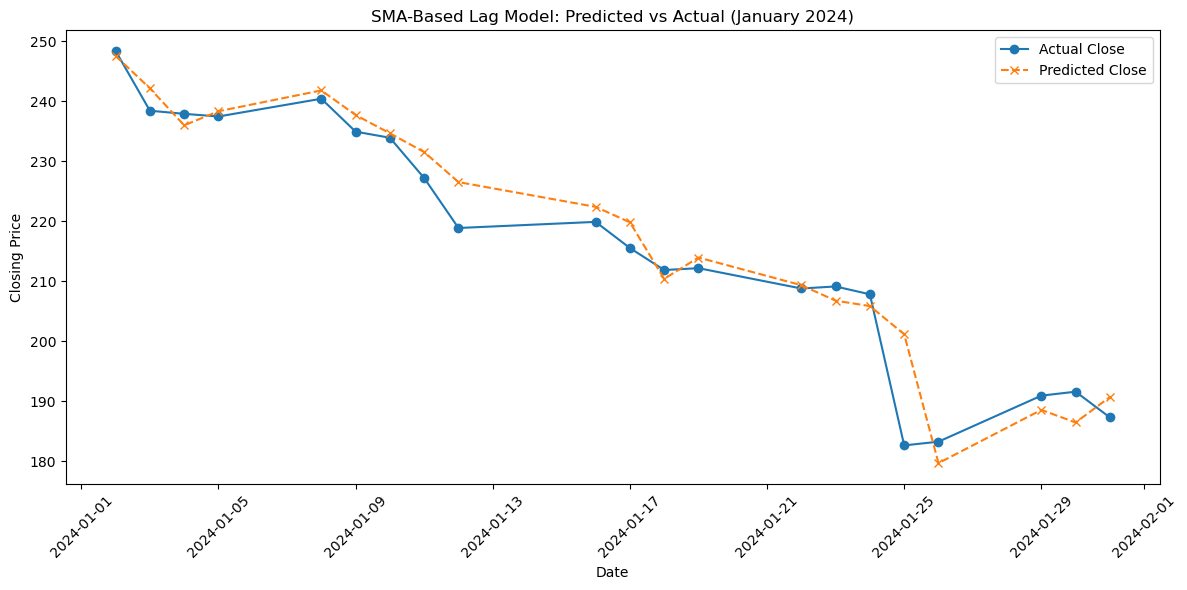


=== EMA-Based Lag Model 2023 Test Performance ===
R²: 0.9921
MSE: 11.9193
RMSE: 3.4524
MAE: 2.6098

=== EMA-Based Lag Model January 2024 Performance ===
R²: 0.9452
MSE: 21.7958
RMSE: 4.6686
MAE: 3.1287


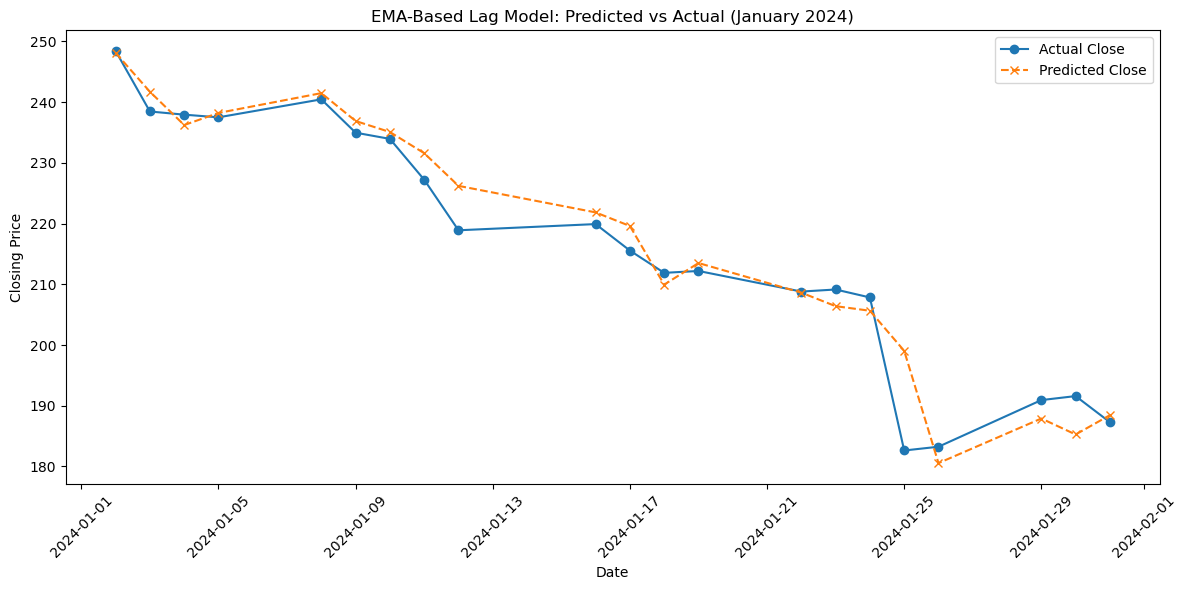


=== Linear Regression + TF-IDF (SMA) 2023 Test Performance ===
R²: 0.9863
MSE: 14.4168
RMSE: 3.797
MAE: 2.6779

=== Linear Regression + TF-IDF (SMA) January 2024 Performance ===
R²: 0.9377
MSE: 24.7954
RMSE: 4.9795
MAE: 3.39


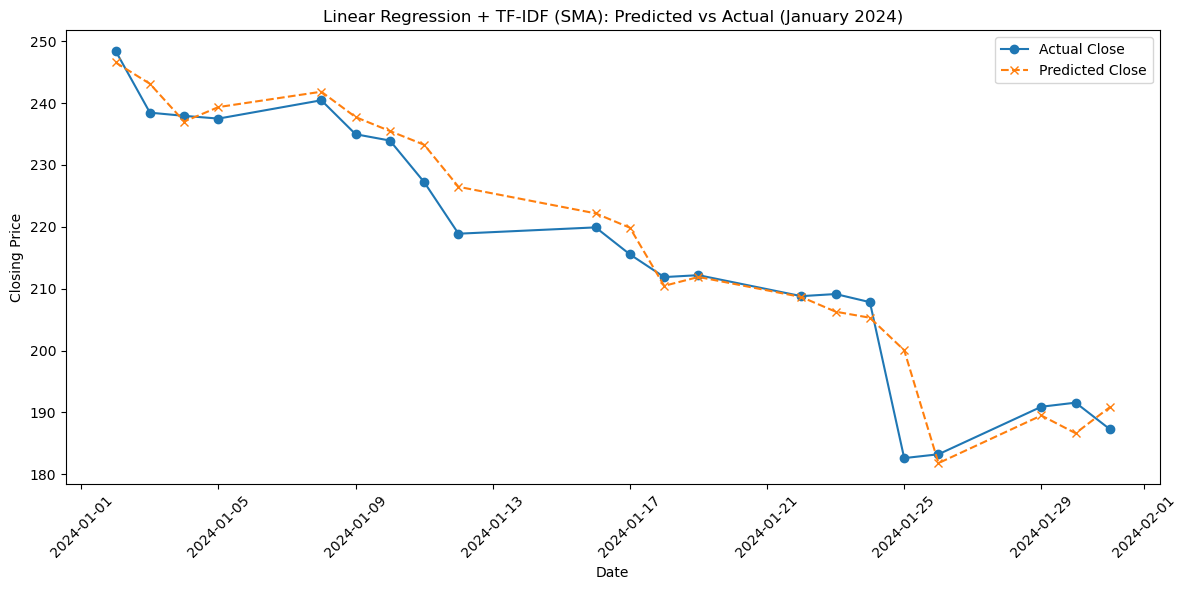


=== Linear Regression + TF-IDF (EMA) 2023 Test Performance ===
R²: 0.9897
MSE: 15.4216
RMSE: 3.927
MAE: 2.9047

=== Linear Regression + TF-IDF (EMA) January 2024 Performance ===
R²: 0.9503
MSE: 19.7967
RMSE: 4.4493
MAE: 3.0568


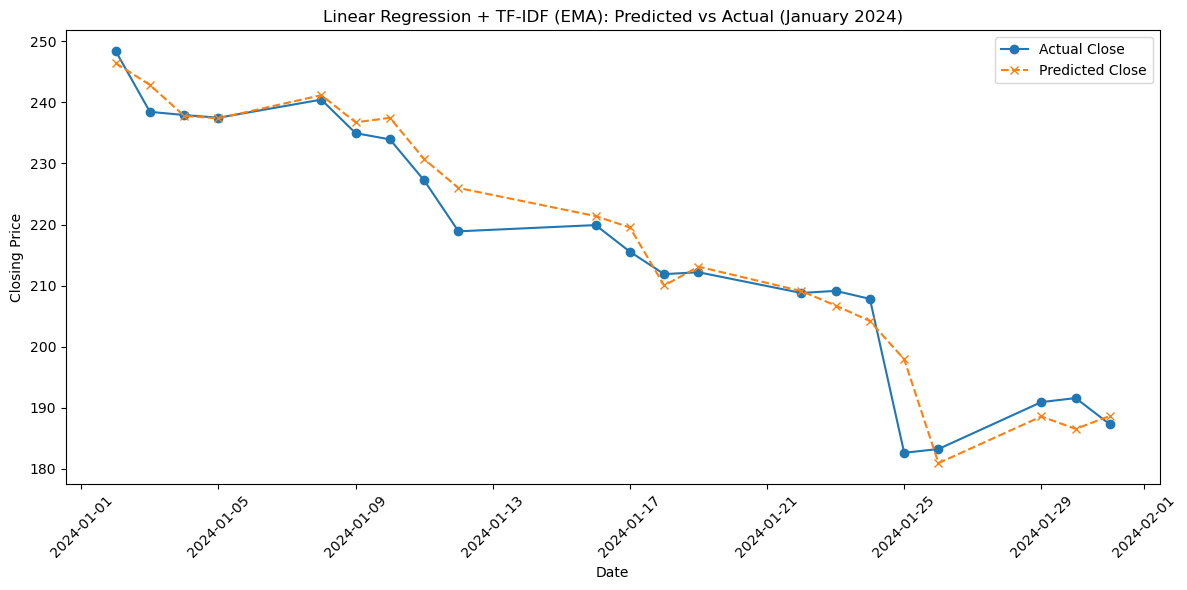


=== Linear Regression + TextBlob (SMA) 2023 Test Performance ===
R²: 0.9852
MSE: 15.5903
RMSE: 3.9485
MAE: 2.7772

=== Linear Regression + TextBlob (SMA) January 2024 Performance ===
R²: 0.9301
MSE: 27.8278
RMSE: 5.2752
MAE: 3.5141


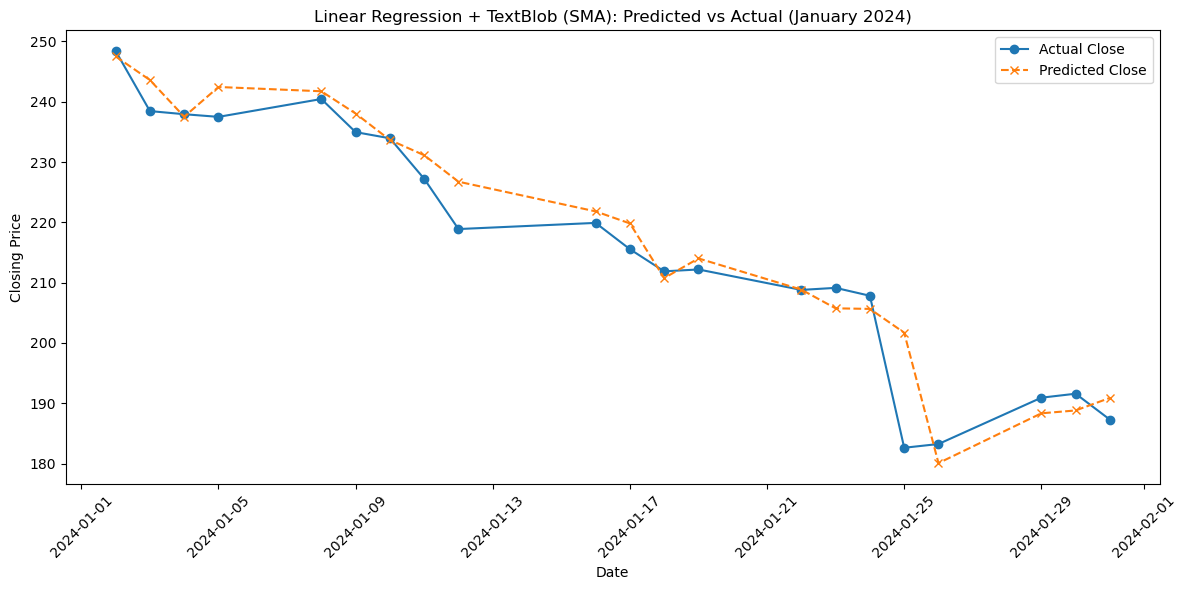


=== Linear Regression + TextBlob (EMA) 2023 Test Performance ===
R²: 0.9913
MSE: 13.0077
RMSE: 3.6066
MAE: 2.7687

=== Linear Regression + TextBlob (EMA) January 2024 Performance ===
R²: 0.9451
MSE: 21.8617
RMSE: 4.6757
MAE: 3.2224


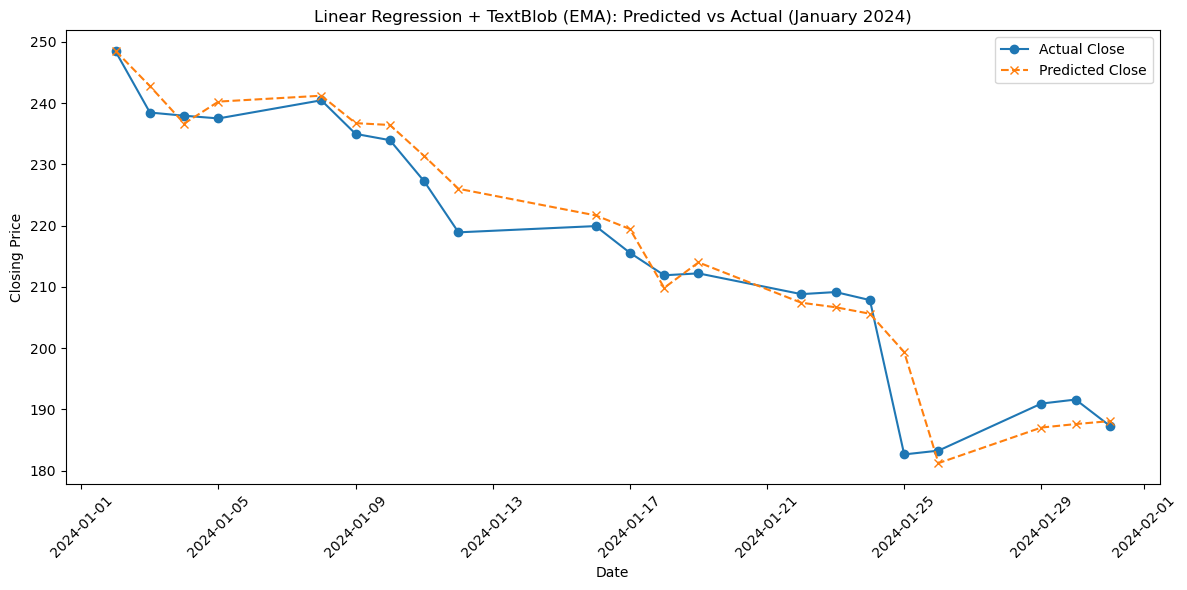


=== Linear Regression + VADER (SMA) 2023 Test Performance ===
R²: 0.987
MSE: 13.7566
RMSE: 3.709
MAE: 2.7116

=== Linear Regression + VADER (SMA) January 2024 Performance ===
R²: 0.9343
MSE: 26.1486
RMSE: 5.1136
MAE: 3.2879


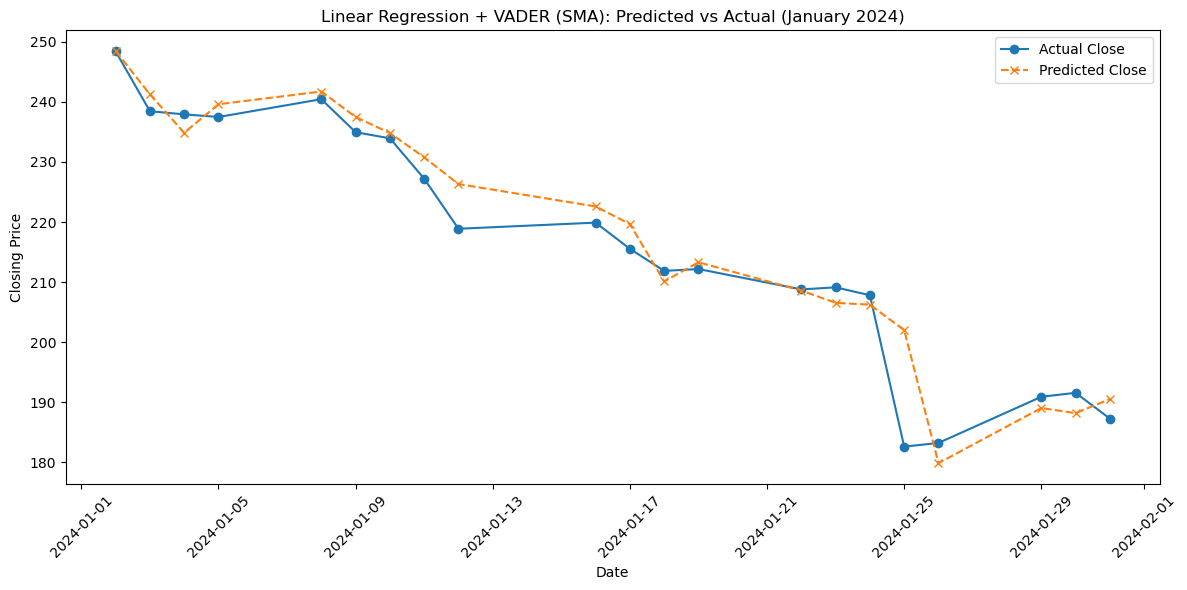


=== Linear Regression + VADER (EMA) 2023 Test Performance ===
R²: 0.9914
MSE: 12.8658
RMSE: 3.5869
MAE: 2.6877

=== Linear Regression + VADER (EMA) January 2024 Performance ===
R²: 0.9463
MSE: 21.367
RMSE: 4.6224
MAE: 3.0673


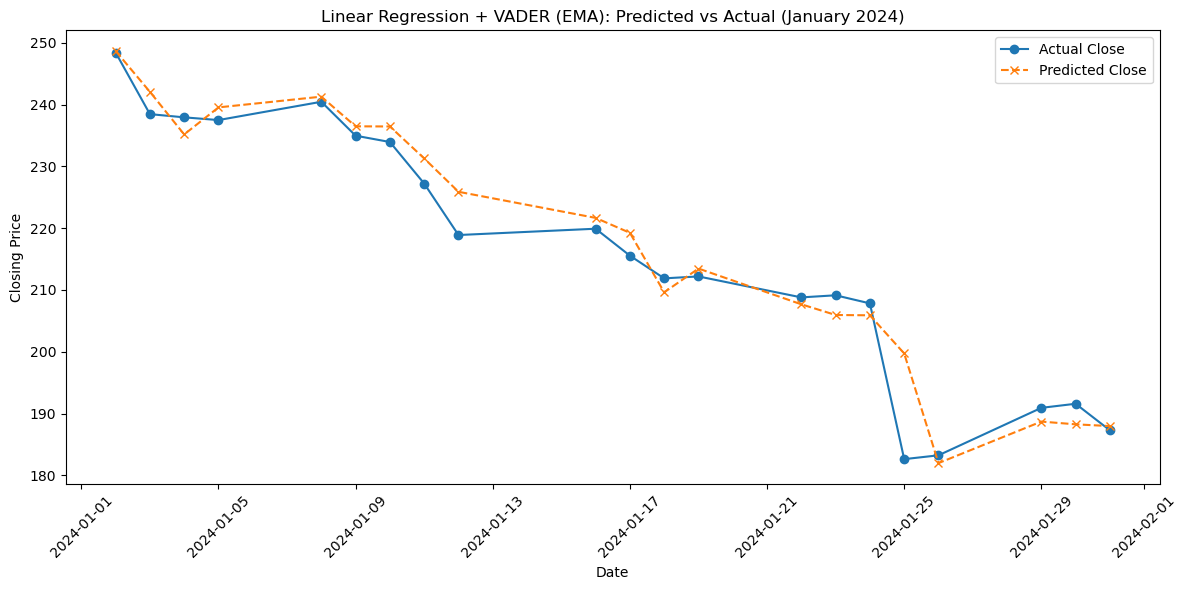


=== Model Comparison Summary ===
                                Model  Test_R²   Test_MSE  Jan_R²   Jan_MSE
0                          Base Model   0.0912  1432.4078 -0.5639  622.4621
1                 SMA-Based Lag Model   0.9877    13.0181  0.9346   26.0316
2                 EMA-Based Lag Model   0.9921    11.9193  0.9452   21.7958
3    Linear Regression + TF-IDF (SMA)   0.9863    14.4168  0.9377   24.7954
4    Linear Regression + TF-IDF (EMA)   0.9897    15.4216  0.9503   19.7967
5  Linear Regression + TextBlob (SMA)   0.9852    15.5903  0.9301   27.8278
6  Linear Regression + TextBlob (EMA)   0.9913    13.0077  0.9451   21.8617
7     Linear Regression + VADER (SMA)   0.9870    13.7566  0.9343   26.1486
8     Linear Regression + VADER (EMA)   0.9914    12.8658  0.9463   21.3670


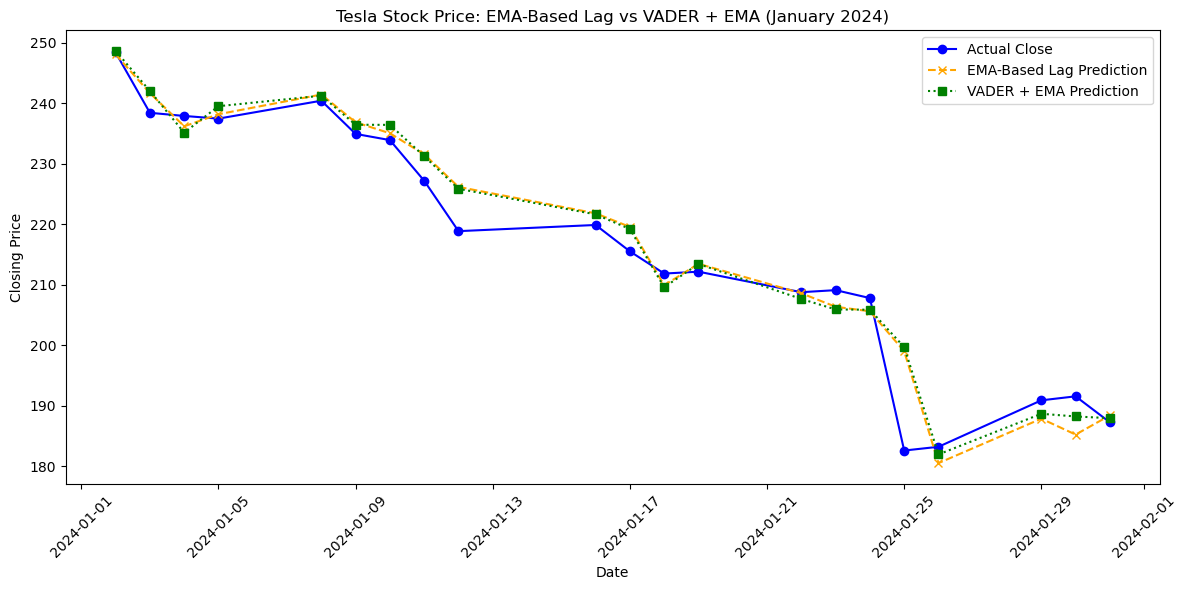

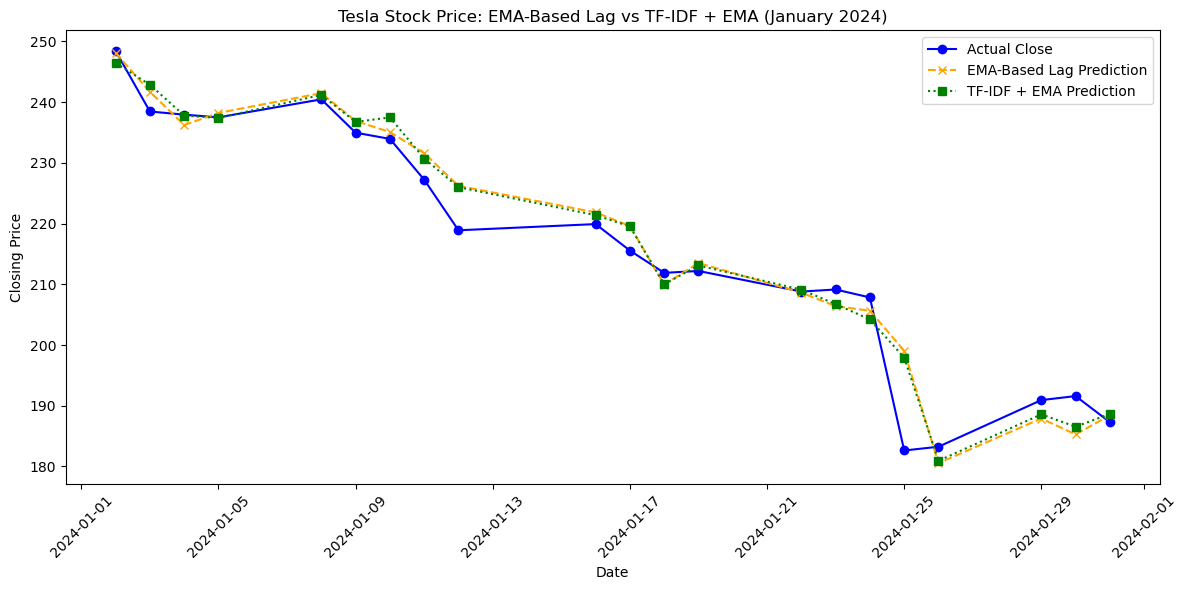

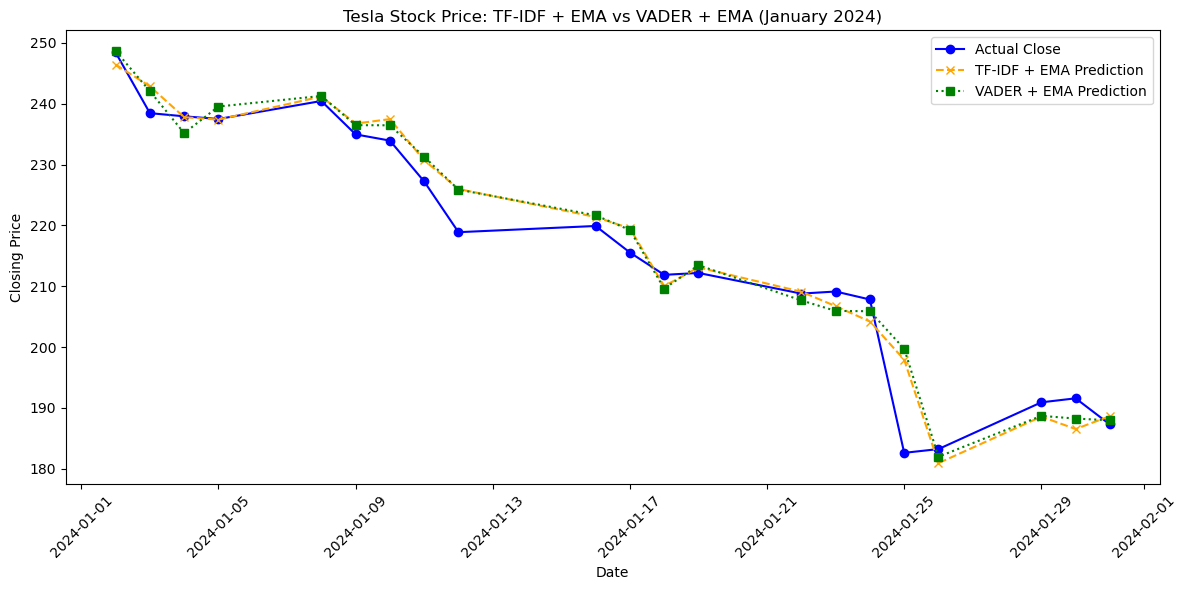

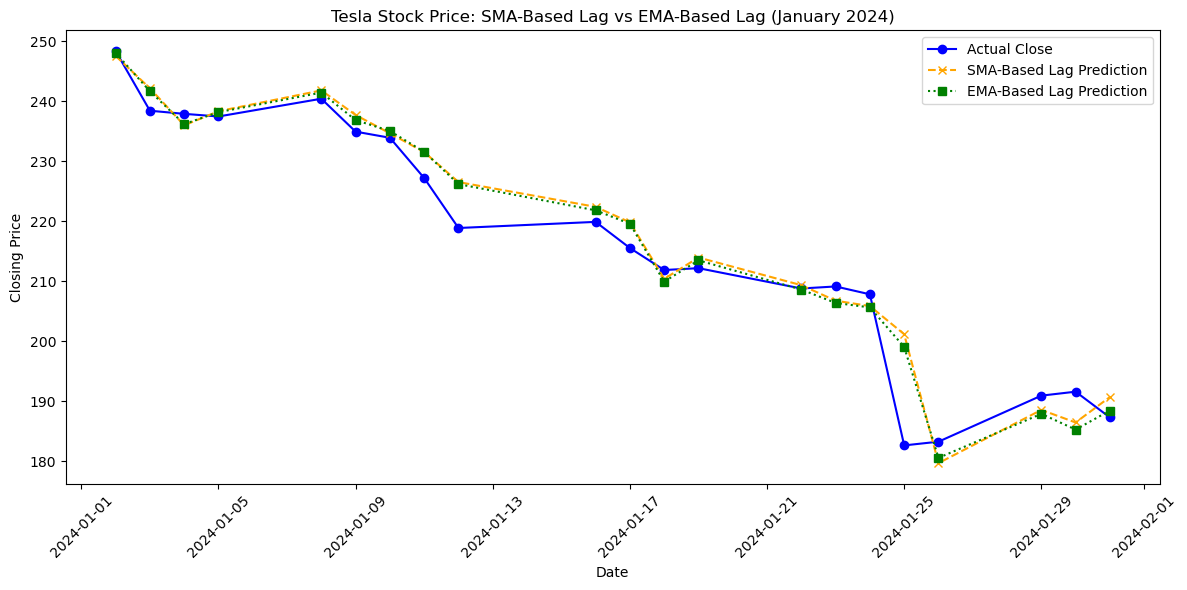

In [ ]:
# =========================================
# TESLA STOCK PREDICTION
# Base / SMA / EMA / TF-IDF / TextBlob / VADER
# =========================================
# %%
# If needed:
# pip install yfinance pandas numpy scikit-learn matplotlib nltk textblob

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk

from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

nltk.download("vader_lexicon")

# =========================================
# 1. Load Tesla stock data
# =========================================
ticker = "TSLA"
data = yf.download(ticker, start="2023-01-01", end="2024-02-01")
data.reset_index(inplace=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data["Date"] = pd.to_datetime(data["Date"])

# =========================================
# 2. Base stock features
# =========================================
data["Open_Close_Diff"] = data["Open"] - data["Close"]
data["High_Low_Range"] = data["High"] - data["Low"]
data["Volume_Change_Pct"] = data["Volume"].pct_change()
data["Squared_High_Low_Range"] = data["High_Low_Range"] ** 2

data["Close_lag_1"] = data["Close"].shift(1)
data["Close_lag_5"] = data["Close"].shift(5)

data["SMA_10"] = data["Close"].rolling(window=10).mean()
data["SMA_20"] = data["Close"].rolling(window=20).mean()

data["EMA_10"] = data["Close"].ewm(span=10, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

base_data = data.copy()
target_col = "Close"

# =========================================
# 3. Load and prepare combined news
# =========================================
news = pd.read_csv("combined_tesla_news_clean.csv")
news["date"] = pd.to_datetime(news["date"], errors="coerce").dt.floor("D")
news["title"] = news["title"].fillna("")
news["summary"] = news["summary"].fillna("")
news["text_for_nlp"] = (
    news["title"].str.strip() + " " + news["summary"].str.strip()
).str.strip()

news = news.dropna(subset=["date"]).copy()
news = news[news["text_for_nlp"] != ""].copy()

# =========================================
# 4. Build TF-IDF daily news features
# =========================================
daily_text = news.groupby("date").agg(
    article_count=("text_for_nlp", "count"),
    combined_text=("text_for_nlp", lambda x: " ".join(x))
).reset_index()

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=300,
    ngram_range=(1, 2)
)

tfidf_matrix = vectorizer.fit_transform(daily_text["combined_text"])
svd = TruncatedSVD(n_components=10, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

tfidf_cols = [f"tfidf_feature_{i+1}" for i in range(tfidf_reduced.shape[1])]
tfidf_df = pd.DataFrame(tfidf_reduced, columns=tfidf_cols, index=daily_text.index)

daily_news_tfidf = pd.concat(
    [
        daily_text[["date", "article_count"]].reset_index(drop=True),
        tfidf_df.reset_index(drop=True)
    ],
    axis=1
)

daily_news_tfidf = daily_news_tfidf.sort_values("date").reset_index(drop=True)
daily_news_tfidf["article_count_lag_1"] = daily_news_tfidf["article_count"].shift(1)
daily_news_tfidf = daily_news_tfidf.fillna(0)

# =========================================
# 5. Build daily sentiment features
# =========================================
sia = SentimentIntensityAnalyzer()

news["textblob_sentiment"] = news["text_for_nlp"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

news["vader_sentiment"] = news["text_for_nlp"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

daily_sentiment = news.groupby("date").agg(
    article_count=("text_for_nlp", "count"),
    textblob_avg=("textblob_sentiment", "mean"),
    textblob_max=("textblob_sentiment", "max"),
    textblob_min=("textblob_sentiment", "min"),
    vader_avg=("vader_sentiment", "mean"),
    vader_max=("vader_sentiment", "max"),
    vader_min=("vader_sentiment", "min")
).reset_index()

daily_sentiment = daily_sentiment.sort_values("date").reset_index(drop=True)
daily_sentiment["article_count_lag_1"] = daily_sentiment["article_count"].shift(1)
daily_sentiment["textblob_avg_lag_1"] = daily_sentiment["textblob_avg"].shift(1)
daily_sentiment["vader_avg_lag_1"] = daily_sentiment["vader_avg"].shift(1)
daily_sentiment = daily_sentiment.fillna(0)

# =========================================
# 6. Feature sets
# =========================================
base_feature_cols = [
    "Open_Close_Diff",
    "High_Low_Range",
    "Volume_Change_Pct",
    "Squared_High_Low_Range"
]

sma_feature_cols = base_feature_cols + [
    "Close_lag_1",
    "Close_lag_5",
    "SMA_10",
    "SMA_20"
]

ema_feature_cols = base_feature_cols + [
    "Close_lag_1",
    "Close_lag_5",
    "EMA_10",
    "EMA_20"
]

# =========================================
# 7. Helper functions
# =========================================
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

def run_plain_model(model_name, data_in, stock_feature_cols):
    df = data_in.copy()
    df = df.dropna(subset=stock_feature_cols + [target_col]).copy()

    model_data = df[(df["Date"] >= "2023-01-01") & (df["Date"] < "2024-01-01")].copy()
    jan_2024_data = df[(df["Date"] >= "2024-01-01") & (df["Date"] < "2024-02-01")].copy()

    X = model_data[stock_feature_cols]
    y = model_data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(y_test, y_pred)

    print(f"\n=== {model_name} 2023 Test Performance ===")
    print("R²:", round(test_r2, 4))
    print("MSE:", round(test_mse, 4))
    print("RMSE:", round(test_rmse, 4))
    print("MAE:", round(test_mae, 4))

    X_jan = jan_2024_data[stock_feature_cols]
    jan_2024_data["Predicted_Close"] = model.predict(X_jan)

    jan_mae, jan_mse, jan_rmse, jan_r2 = calculate_metrics(
        jan_2024_data["Close"], jan_2024_data["Predicted_Close"]
    )

    print(f"\n=== {model_name} January 2024 Performance ===")
    print("R²:", round(jan_r2, 4))
    print("MSE:", round(jan_mse, 4))
    print("RMSE:", round(jan_rmse, 4))
    print("MAE:", round(jan_mae, 4))

    plt.figure(figsize=(12, 6))
    plt.plot(jan_2024_data["Date"], jan_2024_data["Close"], label="Actual Close", marker="o")
    plt.plot(jan_2024_data["Date"], jan_2024_data["Predicted_Close"], label="Predicted Close", linestyle="--", marker="x")
    plt.title(f"{model_name}: Predicted vs Actual (January 2024)")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Test_R2": test_r2,
        "Test_MSE": test_mse,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Jan_R2": jan_r2,
        "Jan_MSE": jan_mse,
        "Jan_RMSE": jan_rmse,
        "Jan_MAE": jan_mae,
        "Predictions": jan_2024_data[["Date", "Close", "Predicted_Close"]].copy()
    }

def run_tfidf_model(model_name, data_in, stock_feature_cols):
    df = data_in.copy()
    df = pd.merge(df, daily_news_tfidf, left_on="Date", right_on="date", how="left")
    df.drop(columns=["date"], inplace=True)

    news_cols = ["article_count", "article_count_lag_1"] + tfidf_cols
    for col in news_cols:
        df[col] = df[col].fillna(0)

    feature_cols = stock_feature_cols + ["article_count", "article_count_lag_1"] + tfidf_cols
    df = df.dropna(subset=stock_feature_cols + [target_col]).copy()

    model_data = df[(df["Date"] >= "2023-01-01") & (df["Date"] < "2024-01-01")].copy()
    jan_2024_data = df[(df["Date"] >= "2024-01-01") & (df["Date"] < "2024-02-01")].copy()

    X = model_data[feature_cols]
    y = model_data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(y_test, y_pred)

    print(f"\n=== {model_name} 2023 Test Performance ===")
    print("R²:", round(test_r2, 4))
    print("MSE:", round(test_mse, 4))
    print("RMSE:", round(test_rmse, 4))
    print("MAE:", round(test_mae, 4))

    X_jan = jan_2024_data[feature_cols]
    jan_2024_data["Predicted_Close"] = model.predict(X_jan)

    jan_mae, jan_mse, jan_rmse, jan_r2 = calculate_metrics(
        jan_2024_data["Close"], jan_2024_data["Predicted_Close"]
    )

    print(f"\n=== {model_name} January 2024 Performance ===")
    print("R²:", round(jan_r2, 4))
    print("MSE:", round(jan_mse, 4))
    print("RMSE:", round(jan_rmse, 4))
    print("MAE:", round(jan_mae, 4))

    plt.figure(figsize=(12, 6))
    plt.plot(jan_2024_data["Date"], jan_2024_data["Close"], label="Actual Close", marker="o")
    plt.plot(jan_2024_data["Date"], jan_2024_data["Predicted_Close"], label="Predicted Close", linestyle="--", marker="x")
    plt.title(f"{model_name}: Predicted vs Actual (January 2024)")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Test_R2": test_r2,
        "Test_MSE": test_mse,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Jan_R2": jan_r2,
        "Jan_MSE": jan_mse,
        "Jan_RMSE": jan_rmse,
        "Jan_MAE": jan_mae,
        "Predictions": jan_2024_data[["Date", "Close", "Predicted_Close"]].copy()
    }

def run_sentiment_model(model_name, data_in, stock_feature_cols, sentiment_type="textblob"):
    df = data_in.copy()
    df = pd.merge(df, daily_sentiment, left_on="Date", right_on="date", how="left")
    df.drop(columns=["date"], inplace=True)

    if sentiment_type == "textblob":
        sent_cols = [
            "article_count", "article_count_lag_1",
            "textblob_avg", "textblob_max", "textblob_min", "textblob_avg_lag_1"
        ]
    else:
        sent_cols = [
            "article_count", "article_count_lag_1",
            "vader_avg", "vader_max", "vader_min", "vader_avg_lag_1"
        ]

    for col in sent_cols:
        df[col] = df[col].fillna(0)

    feature_cols = stock_feature_cols + sent_cols
    df = df.dropna(subset=stock_feature_cols + [target_col]).copy()

    model_data = df[(df["Date"] >= "2023-01-01") & (df["Date"] < "2024-01-01")].copy()
    jan_2024_data = df[(df["Date"] >= "2024-01-01") & (df["Date"] < "2024-02-01")].copy()

    X = model_data[feature_cols]
    y = model_data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(y_test, y_pred)

    print(f"\n=== {model_name} 2023 Test Performance ===")
    print("R²:", round(test_r2, 4))
    print("MSE:", round(test_mse, 4))
    print("RMSE:", round(test_rmse, 4))
    print("MAE:", round(test_mae, 4))

    X_jan = jan_2024_data[feature_cols]
    jan_2024_data["Predicted_Close"] = model.predict(X_jan)

    jan_mae, jan_mse, jan_rmse, jan_r2 = calculate_metrics(
        jan_2024_data["Close"], jan_2024_data["Predicted_Close"]
    )

    print(f"\n=== {model_name} January 2024 Performance ===")
    print("R²:", round(jan_r2, 4))
    print("MSE:", round(jan_mse, 4))
    print("RMSE:", round(jan_rmse, 4))
    print("MAE:", round(jan_mae, 4))

    plt.figure(figsize=(12, 6))
    plt.plot(jan_2024_data["Date"], jan_2024_data["Close"], label="Actual Close", marker="o")
    plt.plot(jan_2024_data["Date"], jan_2024_data["Predicted_Close"], label="Predicted Close", linestyle="--", marker="x")
    plt.title(f"{model_name}: Predicted vs Actual (January 2024)")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Test_R2": test_r2,
        "Test_MSE": test_mse,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Jan_R2": jan_r2,
        "Jan_MSE": jan_mse,
        "Jan_RMSE": jan_rmse,
        "Jan_MAE": jan_mae,
        "Predictions": jan_2024_data[["Date", "Close", "Predicted_Close"]].copy()
    }

# =========================================
# 8. Run models
# =========================================
result_base = run_plain_model("Base Model", base_data, base_feature_cols)
result_sma = run_plain_model("SMA-Based Lag Model", base_data, sma_feature_cols)
result_ema = run_plain_model("EMA-Based Lag Model", base_data, ema_feature_cols)

result_tfidf_sma = run_tfidf_model("Linear Regression + TF-IDF (SMA)", base_data, sma_feature_cols)
result_tfidf_ema = run_tfidf_model("Linear Regression + TF-IDF (EMA)", base_data, ema_feature_cols)

result_textblob_sma = run_sentiment_model("Linear Regression + TextBlob (SMA)", base_data, sma_feature_cols, sentiment_type="textblob")
result_textblob_ema = run_sentiment_model("Linear Regression + TextBlob (EMA)", base_data, ema_feature_cols, sentiment_type="textblob")

result_vader_sma = run_sentiment_model("Linear Regression + VADER (SMA)", base_data, sma_feature_cols, sentiment_type="vader")
result_vader_ema = run_sentiment_model("Linear Regression + VADER (EMA)", base_data, ema_feature_cols, sentiment_type="vader")

# =========================================
# 9. Summary table
# =========================================
results_df = pd.DataFrame([
    {"Model": result_base["Model"], "Test_R²": result_base["Test_R2"], "Test_MSE": result_base["Test_MSE"], "Jan_R²": result_base["Jan_R2"], "Jan_MSE": result_base["Jan_MSE"]},
    {"Model": result_sma["Model"], "Test_R²": result_sma["Test_R2"], "Test_MSE": result_sma["Test_MSE"], "Jan_R²": result_sma["Jan_R2"], "Jan_MSE": result_sma["Jan_MSE"]},
    {"Model": result_ema["Model"], "Test_R²": result_ema["Test_R2"], "Test_MSE": result_ema["Test_MSE"], "Jan_R²": result_ema["Jan_R2"], "Jan_MSE": result_ema["Jan_MSE"]},
    {"Model": result_tfidf_sma["Model"], "Test_R²": result_tfidf_sma["Test_R2"], "Test_MSE": result_tfidf_sma["Test_MSE"], "Jan_R²": result_tfidf_sma["Jan_R2"], "Jan_MSE": result_tfidf_sma["Jan_MSE"]},
    {"Model": result_tfidf_ema["Model"], "Test_R²": result_tfidf_ema["Test_R2"], "Test_MSE": result_tfidf_ema["Test_MSE"], "Jan_R²": result_tfidf_ema["Jan_R2"], "Jan_MSE": result_tfidf_ema["Jan_MSE"]},
    {"Model": result_textblob_sma["Model"], "Test_R²": result_textblob_sma["Test_R2"], "Test_MSE": result_textblob_sma["Test_MSE"], "Jan_R²": result_textblob_sma["Jan_R2"], "Jan_MSE": result_textblob_sma["Jan_MSE"]},
    {"Model": result_textblob_ema["Model"], "Test_R²": result_textblob_ema["Test_R2"], "Test_MSE": result_textblob_ema["Test_MSE"], "Jan_R²": result_textblob_ema["Jan_R2"], "Jan_MSE": result_textblob_ema["Jan_MSE"]},
    {"Model": result_vader_sma["Model"], "Test_R²": result_vader_sma["Test_R2"], "Test_MSE": result_vader_sma["Test_MSE"], "Jan_R²": result_vader_sma["Jan_R2"], "Jan_MSE": result_vader_sma["Jan_MSE"]},
    {"Model": result_vader_ema["Model"], "Test_R²": result_vader_ema["Test_R2"], "Test_MSE": result_vader_ema["Test_MSE"], "Jan_R²": result_vader_ema["Jan_R2"], "Jan_MSE": result_vader_ema["Jan_MSE"]},
])

print("\n=== Model Comparison Summary ===")
print(results_df.round(4))




# =========================================
# 10. Final plot 1: EMA-based lag vs VADER + EMA
# =========================================
ema_compare = result_ema["Predictions"].rename(columns={"Predicted_Close": "Pred_EMA"})
vader_ema_compare = result_vader_ema["Predictions"].rename(
    columns={"Predicted_Close": "Pred_VADER_EMA"}
)[["Date", "Pred_VADER_EMA"]]

compare_df_1 = pd.merge(ema_compare, vader_ema_compare, on="Date", how="inner")

plt.figure(figsize=(12, 6))
plt.plot(compare_df_1["Date"], compare_df_1["Close"], label="Actual Close", marker="o", color="blue")
plt.plot(compare_df_1["Date"], compare_df_1["Pred_EMA"], label="EMA-Based Lag Prediction", linestyle="--", marker="x", color="orange")
plt.plot(compare_df_1["Date"], compare_df_1["Pred_VADER_EMA"], label="VADER + EMA Prediction", linestyle=":", marker="s", color="green")
plt.title("Tesla Stock Price: EMA-Based Lag vs VADER + EMA (January 2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 11. Final plot 2: EMA-based lag vs TF-IDF + EMA
# =========================================
tfidf_ema_compare = result_tfidf_ema["Predictions"].rename(
    columns={"Predicted_Close": "Pred_TFIDF_EMA"}
)[["Date", "Pred_TFIDF_EMA"]]

compare_df_2 = pd.merge(ema_compare, tfidf_ema_compare, on="Date", how="inner")

plt.figure(figsize=(12, 6))
plt.plot(compare_df_2["Date"], compare_df_2["Close"], label="Actual Close", marker="o", color="blue")
plt.plot(compare_df_2["Date"], compare_df_2["Pred_EMA"], label="EMA-Based Lag Prediction", linestyle="--", marker="x", color="orange")
plt.plot(compare_df_2["Date"], compare_df_2["Pred_TFIDF_EMA"], label="TF-IDF + EMA Prediction", linestyle=":", marker="s", color="green")
plt.title("Tesla Stock Price: EMA-Based Lag vs TF-IDF + EMA (January 2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 12. Final plot 3: TF-IDF + EMA vs VADER + EMA
# =========================================
compare_df_3 = pd.merge(tfidf_ema_compare, vader_ema_compare, on="Date", how="inner")
compare_df_3 = pd.merge(
    result_tfidf_ema["Predictions"][["Date", "Close"]],
    compare_df_3,
    on="Date",
    how="inner"
)

plt.figure(figsize=(12, 6))
plt.plot(compare_df_3["Date"], compare_df_3["Close"], label="Actual Close", marker="o", color="blue")
plt.plot(compare_df_3["Date"], compare_df_3["Pred_TFIDF_EMA"], label="TF-IDF + EMA Prediction", linestyle="--", marker="x", color="orange")
plt.plot(compare_df_3["Date"], compare_df_3["Pred_VADER_EMA"], label="VADER + EMA Prediction", linestyle=":", marker="s", color="green")
plt.title("Tesla Stock Price: TF-IDF + EMA vs VADER + EMA (January 2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 13. Final plot 4: SMA-based lag vs EMA-based lag
# =========================================
sma_compare = result_sma["Predictions"].rename(columns={"Predicted_Close": "Pred_SMA"})
ema_compare_2 = result_ema["Predictions"].rename(columns={"Predicted_Close": "Pred_EMA"})[["Date", "Pred_EMA"]]

compare_df_4 = pd.merge(sma_compare, ema_compare_2, on="Date", how="inner")

plt.figure(figsize=(12, 6))
plt.plot(compare_df_4["Date"], compare_df_4["Close"], label="Actual Close", marker="o", color="blue")
plt.plot(compare_df_4["Date"], compare_df_4["Pred_SMA"], label="SMA-Based Lag Prediction", linestyle="--", marker="x", color="orange")
plt.plot(compare_df_4["Date"], compare_df_4["Pred_EMA"], label="EMA-Based Lag Prediction", linestyle=":", marker="s", color="green")
plt.title("Tesla Stock Price: SMA-Based Lag vs EMA-Based Lag (January 2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()